In [140]:
import h5py
import numpy as np
import pandas as pd
import random
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import corner

from scipy import stats
from astroML.utils import completeness_contamination
from astroML.classification import GMMBayes

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score, 
    roc_curve, 
    roc_auc_score, 
    auc, 
    confusion_matrix, 
    average_precision_score,
    ConfusionMatrixDisplay
)
import tensorflow
from tensorflow import keras

Can a computern learn if we're going to detect a GW?

In [116]:
with h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file:
    
    keys = list(file.keys())
    print(keys)
    
    data = {}
    for key in keys:
        data[key] = file[key][:]

total_samples = len(data['det'])
print (f"Total samples:{total_samples}")

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
Total samples:20000000


In [117]:
# Possibility of downsampling
N_samples = total_samples // 1

idx = np.random.choice(total_samples, N_samples, replace=False)

par_keys = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z'] # remove snr
lab_keys = ['det']

# Create X and y 
X = np.stack([data[k][idx] for k in par_keys], axis=1)
y = data['det'][idx].astype(int)

# Split between train and test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

# Split between train and validation (No cross validation inside the neural network)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=52)


# Rescale the data
X_mean = X_train.mean(axis=0, keepdims=True)
X_mean_full = X_train_full.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_std_full = X_train_full.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_train_full = (X_train_full - X_mean_full) / X_std_full
X_val = (X_val - X_mean) / X_std
X_test= (X_test - X_mean) / X_std


print(len(X_train))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)


12800000
(12800000, 13)
(3200000, 13)
(4000000, 13)


In [118]:
keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tensorflow.random.set_seed(42)

Create a first MLP model

In [119]:

model = keras.models.Sequential([
   keras.layers.InputLayer(input_shape=[X_train.shape[1]]), 
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=1, activation='sigmoid')
])

print(model.summary())

/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# For binary classification, we use 'binary_crossentropy'
model.compile(
    loss="binary_crossentropy", 
    optimizer="adam", #default value 0.001
    metrics=[keras.metrics.Precision(name='precision'),
        keras.metrics.AUC(curve='PR', name='pr_auc')]
)

Train the model

In [125]:
clf = model.fit(
    X_train, y_train, 
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=1024
)

#default values of batch size=32 is too small (weight must be modify too often and so the fit is slower)

Epoch 1/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 0.0669 - pr_auc: 0.9689 - precision: 0.9071 - val_loss: 0.0561 - val_pr_auc: 0.9797 - val_precision: 0.9300
Epoch 2/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0654 - pr_auc: 0.9702 - precision: 0.9095 - val_loss: 0.0547 - val_pr_auc: 0.9813 - val_precision: 0.9338
Epoch 3/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0641 - pr_auc: 0.9712 - precision: 0.9116 - val_loss: 0.0532 - val_pr_auc: 0.9822 - val_precision: 0.9397
Epoch 4/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 0.0626 - pr_auc: 0.9724 - precision: 0.9141 - val_loss: 0.0517 - val_pr_auc: 0.9834 - val_precision: 0.9404
Epoch 5/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 0.0618 - pr_auc: 0.9731 - precision: 0.9160 - val_loss: 0.0514 - val_pr_auc: 0.9841 - val_precision: 0.9473
Epoch 6/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0611 - pr_auc: 0.9736 - precision: 0.9165 - val_loss: 0.0518 - val_p

Plot how AUC PR score changes in function of the epoch

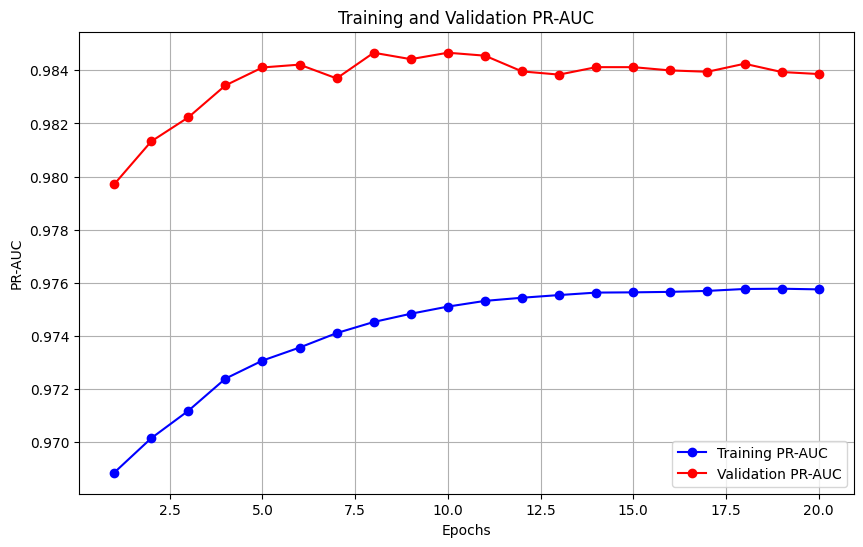

In [126]:
# Extract the data from the 'clf' object (one for each epoch)
train_auc = clf.history['pr_auc']
val_auc = clf.history['val_pr_auc']
epochs = range(1, len(train_auc) + 1)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_auc, 'bo-', label='Training PR-AUC')
plt.plot(epochs, val_auc, 'ro-', label='Validation PR-AUC')

plt.title('Training and Validation PR-AUC')
plt.xlabel('Epochs')
plt.ylabel('PR-AUC')
plt.legend()
plt.grid(True)

plt.show()

Start by plotting the prediction of 10 sample from test set (just to visualize some results)

In [127]:
idx10 = np.random.choice(np.arange(len(y_test)), size=10, replace=False)
X_new = X_test[idx10]
y_true_10 = y_test[idx10]

# Prediction
y_proba_10 = model.predict(X_new, verbose=0).flatten()
y_pred_10 = (y_proba_10 > 0.5).astype(int)

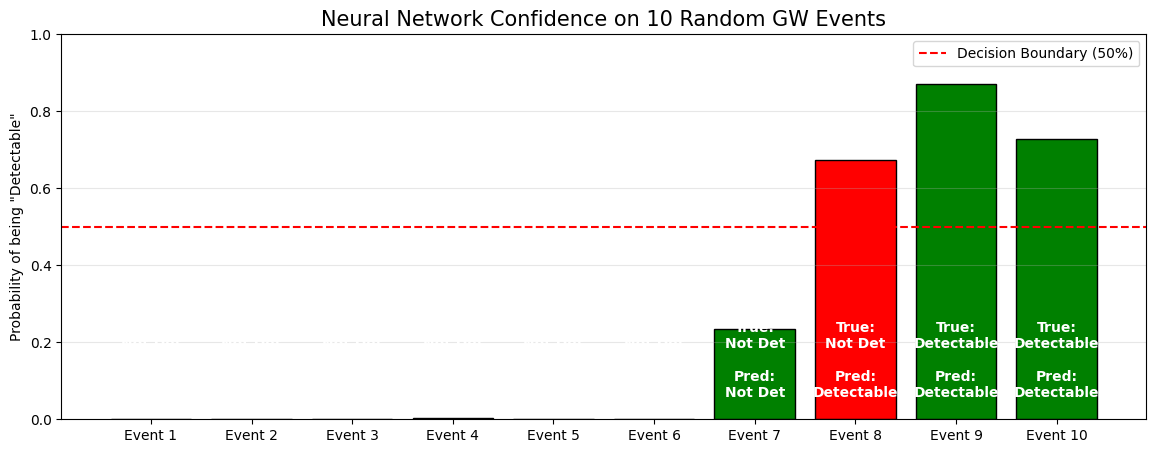

In [128]:
# Plot result for the 10 sample
gw_labels = {0: "Not Det", 1: "Detectable"}

plt.figure(figsize=(14, 5))

# Colorbars: Green if the prediction matches reality, Red if it's an error
colors = ['green' if true == pred else 'red' 
          for true, pred in zip(y_true_10, y_pred_10)]

bars = plt.bar(range(10), y_proba_10, color=colors, edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary (50%)')

for i, bar in enumerate(bars):
    actual = gw_labels[y_true_10[i]]
    pred = gw_labels[y_pred_10[i]]
    plt.text(bar.get_x() + bar.get_width()/2, 0.05, 
             f"True:\n{actual}\n\nPred:\n{pred}", 
             ha='center', va='bottom', color='white', fontweight='bold', fontsize=10)

plt.title('Neural Network Confidence on 10 Random GW Events', fontsize=15)
plt.ylabel('Probability of being "Detectable"')
plt.xticks(range(10), [f"Event {i+1}" for i in range(10)])
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

Now do prediction for the all test set

In [129]:
# Prediction
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_proba > 0.5).astype(int)


Confusion matrix for the all test set

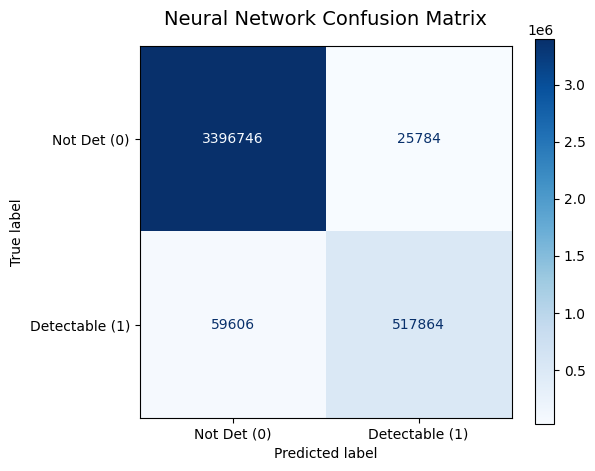

In [130]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)


disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 
plt.title("Neural Network Confusion Matrix", fontsize=14, pad=15)
plt.show()


# Now let's try to improve the neural network Precision

Start by using different combination of layers and unit

In [133]:
# Define Early Stopping to prevent wasting time on bad models
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_pr_auc', 
    patience=3, 
    mode='max',
    restore_best_weights=True
)

In [ ]:
# Define different architectures
architectures = [
    [32, 16],          
    [64, 32],          
    [128, 64, 32],     
    [256, 128, 64]     
]

results = {}

for config in architectures:
    model_name = " -> ".join(map(str, config))
    print(f"\nTraining Model: {model_name}")
    
    keras.backend.clear_session()
    
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]])) # first layer (input) same for each model
    
    for units in config:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(0.3)) #fixed 0.3 dropout
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    # Compilation
    model.compile(
        loss="binary_crossentropy", 
        optimizer="adam", # default value of lr=0.001
        metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    
    # Train 
    history = model.fit(
        X_train, y_train, 
        epochs=10, 
        validation_data=(X_val, y_val), 
        verbose=0,
        batch_size=1024,
        callbacks=[early_stop]
    )
    

    val_pr_auc = max(history.history['val_pr_auc'])
    results[model_name] = val_pr_auc
    print(f"Max Validation PR-AUC: {val_pr_auc:.4f}")

# Find the best configuration
best_config = max(results, key=results.get)
print(f"\nBest configuration {best_config} with {results[best_config]:.4f} PR-AUC")

best_arch = [int(x) for x in best_config.split(" -> ")]




Training Model: 32 -> 16


/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Max Validation PR-AUC: 0.9645

Training Model: 64 -> 32
Max Validation PR-AUC: 0.9850

Training Model: 128 -> 64 -> 32
Max Validation PR-AUC: 0.9910

Training Model: 256 -> 128 -> 64
Max Validation PR-AUC: 0.9937

WINNER: 256 -> 128 -> 64 with 0.9937 PR-AUC


Optimize the learning rate

In [134]:
learning_rates_to_test = [0.01, 0.001, 0.0001, 0.00001]
lr_results = {}
baseline_dropout = 0.3 # Same dropout as before

for lr in learning_rates_to_test:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    # Dynamically build the model using best configuration of previous cell
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
    for units in best_arch:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(baseline_dropout))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    custom_adam = keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')])

    history = model.fit(X_train, y_train, epochs=20, batch_size=1024, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    lr_results[lr] = max(history.history['val_pr_auc'])
    print(f"LR: {lr:.5f} | Max Val PR-AUC: {lr_results[lr]:.4f}")

best_lr = max(lr_results, key=lr_results.get)
print(f"\nBest Learning Rate {best_lr}\n")

LR: 0.01000 | Max Val PR-AUC: 0.9880
LR: 0.00100 | Max Val PR-AUC: 0.9941
LR: 0.00010 | Max Val PR-AUC: 0.9913
LR: 0.00001 | Max Val PR-AUC: 0.9574

Best Learning Rate 0.001 <<<



Optimize dropout rate

In [135]:
dropout_rates_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
dropout_results = {}

for rate in dropout_rates_to_test:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    # # Dynamically build the model using best configuration of previous cell
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
    for units in best_arch:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(rate))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
    model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')])
    
    history = model.fit(X_train, y_train, epochs=20, batch_size=1024, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    dropout_results[rate] = max(history.history['val_pr_auc'])
    print(f"Dropout: {rate:.1f} | Max Val PR-AUC: {dropout_results[rate]:.4f}")

best_dropout = max(dropout_results, key=dropout_results.get)
print(f"\nBest Dropout Rate {best_dropout}\n")

/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Dropout: 0.1 | Max Val PR-AUC: 0.9970
Dropout: 0.2 | Max Val PR-AUC: 0.9936
Dropout: 0.3 | Max Val PR-AUC: 0.9926
Dropout: 0.4 | Max Val PR-AUC: 0.9911
Dropout: 0.5 | Max Val PR-AUC: 0.9896
Dropout: 0.6 | Max Val PR-AUC: 0.9881

Best Dropout Rate 0.1



Train the model with the best parameters

In [136]:
# Final training of best model with best params
keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

# Build the ultimate model
best_model = keras.models.Sequential()
best_model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
for units in best_arch:
    best_model.add(keras.layers.Dense(units, activation='relu'))
    best_model.add(keras.layers.Dropout(best_dropout))
best_model.add(keras.layers.Dense(1, activation='sigmoid'))

custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
best_model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=["accuracy", keras.metrics.AUC(curve='PR', name='pr_auc')])

history = best_model.fit(X_train, y_train, epochs=40, batch_size=1024, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

# Get final predictions on the unseen Test set
y_proba_final = best_model.predict(X_test, verbose=0).flatten()
y_pred_final = (y_proba_final > 0.5).astype(int)

Epoch 1/40
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 89s 7ms/step - accuracy: 0.9793 - loss: 0.0474 - pr_auc: 0.9840 - val_accuracy: 0.9857 - val_loss: 0.0323 - val_pr_auc: 0.9927
Epoch 2/40
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 85s 7ms/step - accuracy: 0.9842 - loss: 0.0356 - pr_auc: 0.9906 - val_accuracy: 0.9866 - val_loss: 0.0302 - val_pr_auc: 0.9938
Epoch 3/40
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 90s 7ms/step - accuracy: 0.9850 - loss: 0.0338 - pr_auc: 0.9915 - val_accuracy: 0.9869 - val_loss: 0.0297 - val_pr_auc: 0.9941


Plot the confusion matrix

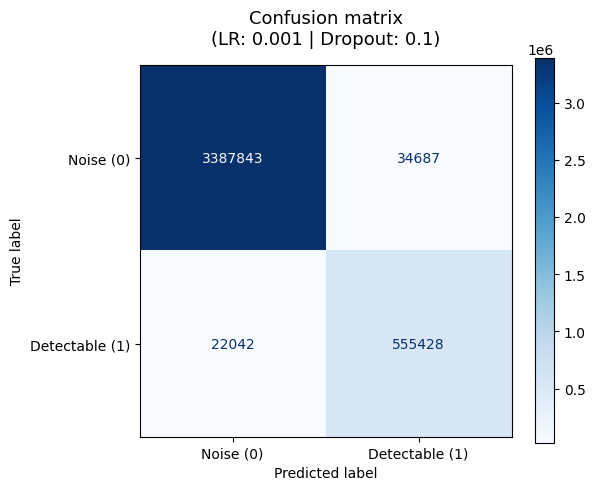

In [137]:
# Plot matrix
cm_best = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best, 
    display_labels=["Noise (0)", "Detectable (1)"]
)

disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 
plt.title(f"Confusion matrix\n(LR: {best_lr} | Dropout: {best_dropout})", fontsize=13, pad=15)
plt.grid(False) # Ensure the grid doesn't overlap the matrix
plt.show()

Now increase the threshold to 0.8 to decrease the false positives

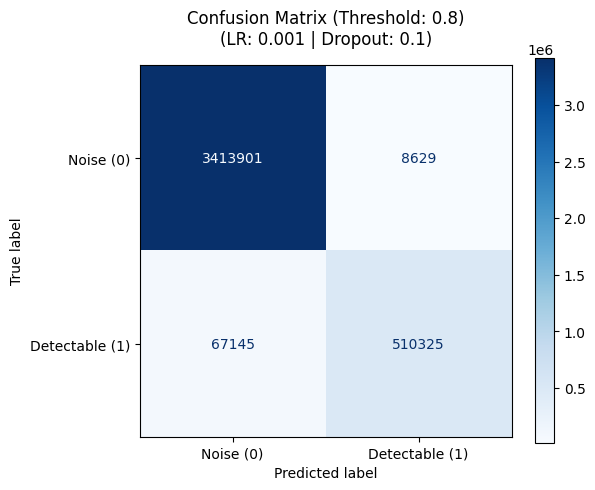

In [138]:
# Set the custom threshold
threshold = 0.8
y_pred_threshold = (y_proba_final > threshold).astype(int)


cm_best = confusion_matrix(y_test, y_pred_threshold)

#Plot
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best, 
    display_labels=["Noise (0)", "Detectable (1)"]
)

disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 

plt.title(f"Confusion Matrix (Threshold: {threshold})\n(LR: {best_lr} | Dropout: {best_dropout})", 
          fontsize=12, pad=15)

plt.grid(False)
plt.show()

Report the metrics

In [141]:
# Calculate metrics for standard threshold (0.5)
y_pred_05 = (y_proba_final > 0.5).astype(int)
acc_05 = accuracy_score(y_test, y_pred_05)
prec_05 = precision_score(y_test, y_pred_05)
rec_05 = recall_score(y_test, y_pred_05)

# Calculate metrics for high-purity threshold (0.8)
y_pred_08 = (y_proba_final > 0.8).astype(int)
acc_08 = accuracy_score(y_test, y_pred_08)
prec_08 = precision_score(y_test, y_pred_08)
rec_08 = recall_score(y_test, y_pred_08)

final_roc_auc = roc_auc_score(y_test, y_proba_final)
final_pr_auc = average_precision_score(y_test, y_proba_final)


print(f"{'Metric':<15} | {'Threshold 0.5':<15} | {'Threshold 0.8':<15}")
print("-" * 45)
print(f"{'Accuracy':<15} | {acc_05:<15.4f} | {acc_08:<15.4f}")
print(f"{'Precision':<15} | {prec_05:<15.4f} | {prec_08:<15.4f}")
print(f"{'Recall':<15} | {rec_05:<15.4f} | {rec_08:<15.4f}")
print("-" * 45)
print(f"{'ROC-AUC':<15} | {final_roc_auc:<33.4f}")
print(f"{'PR-AUC':<15} | {final_pr_auc:<33.4f}")


Metric          | Threshold 0.5   | Threshold 0.8  
---------------------------------------------
Accuracy        | 0.9858          | 0.9811         
Precision       | 0.9412          | 0.9834         
Recall          | 0.9618          | 0.8837         
---------------------------------------------
ROC-AUC         | 0.9988                           
PR-AUC          | 0.9928                           


# Other tests to check the AUC-PR

Adding cv (instead of a fixed validation set into the NN)

In [142]:
# Define the number of folds
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42) #ensure that proportion of classes in each "fold" is the same as the proportion in the entire dataset

cv_pr_auc_scores = []
fold_no = 1

print(f"{k_folds} Fold Cross-Validation")

# Loop through each fold
for train_index, val_index in skf.split(X_train_full, y_train_full):
    
    # Split the data for this specific fold
    X_fold_train, X_fold_val = X_train_full[train_index], X_train_full[val_index]
    y_fold_train, y_fold_val = y_train_full[train_index], y_train_full[val_index]
    
    # Reset everything
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    # Build the model dynamically using previous hyperparameters
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
    for units in best_arch:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(best_dropout))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
    model.compile(
        loss="binary_crossentropy", 
        optimizer=custom_adam, 
        metrics=["accuracy", keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    
    # Define Early Stopping for this specific fold
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_pr_auc', 
        patience=3, 
        mode='max',
        restore_best_weights=True
    )
    
    # Train the model on the current fold
    history = model.fit(
        X_fold_train, y_fold_train, 
        epochs=30, 
        batch_size=1024, 
        validation_data=(X_fold_val, y_fold_val), 
        callbacks=[early_stop], 
        verbose=0
    )
    
    # Evaluate the best epoch on the validation fold
    # Because restore_best_weights=True, this evaluates the model at its peak performance
    scores = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    
    # Keras evaluate returns: [loss, accuracy, pr_auc]
    fold_pr_auc = scores[2] 
    cv_pr_auc_scores.append(fold_pr_auc)
    
    print(f"-> Fold {fold_no} PR-AUC: {fold_pr_auc:.4f}\n")
    fold_no += 1

mean_pr_auc = np.mean(cv_pr_auc_scores)
std_pr_auc = np.std(cv_pr_auc_scores)

print(f"Average PR-AUC: {mean_pr_auc:.4f} ± {std_pr_auc:.4f}")


5 Fold Cross-Validation


/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


-> Fold 1 PR-AUC: 0.9970

-> Fold 2 PR-AUC: 0.9965

-> Fold 3 PR-AUC: 0.9973

-> Fold 4 PR-AUC: 0.9958

-> Fold 5 PR-AUC: 0.9972

Average PR-AUC: 0.9968 ± 0.0006


Train the neural network now with a 90% train and a 10% test

In [143]:
# We no longer need early stopping because we know roughly how many epochs it takes to converge.
# However, to be safe, we can use a validation split of 10% just to trigger early stopping.

keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

best_model = keras.models.Sequential()
best_model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
for units in best_arch:
    best_model.add(keras.layers.Dense(units, activation='relu'))
    best_model.add(keras.layers.Dropout(best_dropout))
best_model.add(keras.layers.Dense(1, activation='sigmoid'))

custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
best_model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=["accuracy", keras.metrics.AUC(curve='PR', name='pr_auc')])

# Train on the entire X_train. We use a dynamic 10% split just to guide the early stopping.
best_model.fit(
    X_train_full, y_train_full, 
    epochs=40, 
    batch_size=1024, 
    validation_split=0.1, 
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/40
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 93s 6ms/step - accuracy: 0.9798 - loss: 0.0462 - pr_auc: 0.9848 - val_accuracy: 0.9861 - val_loss: 0.0317 - val_pr_auc: 0.9931
Epoch 2/40
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 90s 6ms/step - accuracy: 0.9844 - loss: 0.0351 - pr_auc: 0.9908 - val_accuracy: 0.9868 - val_loss: 0.0299 - val_pr_auc: 0.9938
Epoch 3/40
14063/14063 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - accuracy: 0.9851 - loss: 0.0335 - pr_auc: 0.9916 - val_accuracy: 0.9872 - val_loss: 0.0291 - val_pr_auc: 0.9941


Predict on test set

In [144]:

y_proba_final = best_model.predict(X_test, verbose=0).flatten()

y_pred_05 = (y_proba_final > 0.5).astype(int)
y_pred_08 = (y_proba_final > 0.8).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05)
cm_08 = confusion_matrix(y_test, y_pred_08)



 Plot the confusion matrices

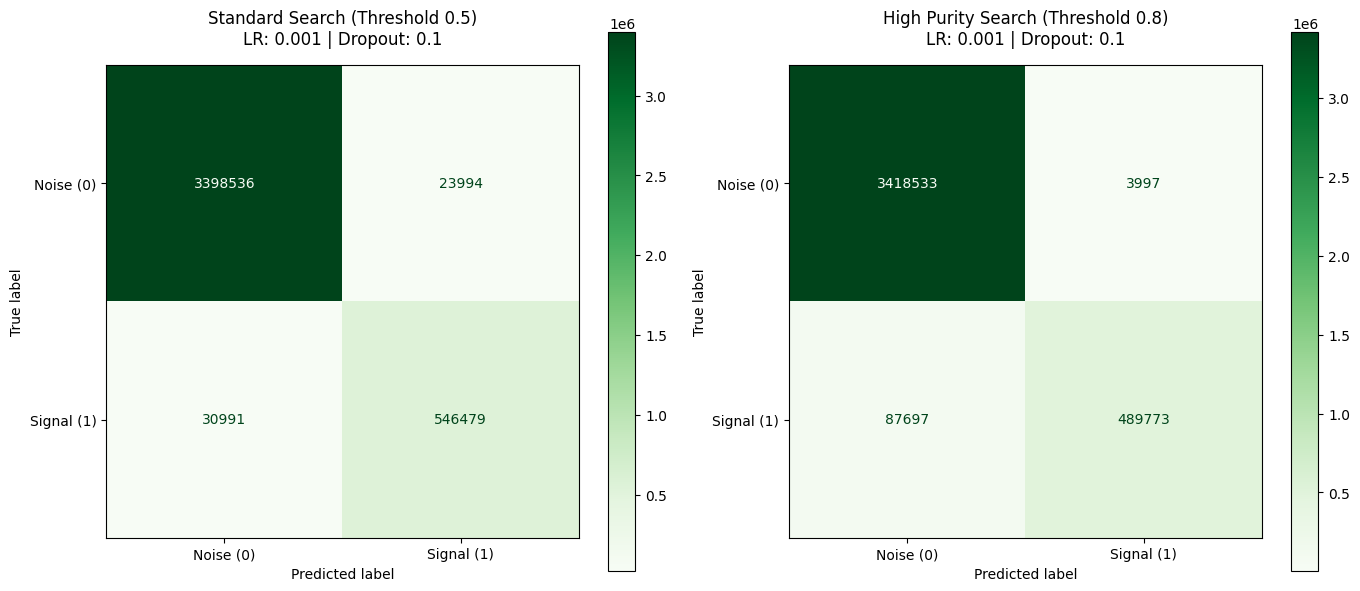

In [145]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Threshold 0.5
disp_05 = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=["Noise (0)", "Signal (1)"])
disp_05.plot(cmap="Greens", values_format="d", ax=axes[0])
axes[0].set_title(f"Standard Search (Threshold 0.5)\nLR: {best_lr} | Dropout: {best_dropout}", fontsize=12, pad=15)
axes[0].grid(False)

# Plot Threshold 0.8
disp_08 = ConfusionMatrixDisplay(confusion_matrix=cm_08, display_labels=["Noise (0)", "Signal (1)"])
disp_08.plot(cmap="Greens", values_format="d", ax=axes[1])
axes[1].set_title(f"High Purity Search (Threshold 0.8)\nLR: {best_lr} | Dropout: {best_dropout}", fontsize=12, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [146]:
# Calculate metrics for standard threshold (0.5)
y_pred_05 = (y_proba_final > 0.5).astype(int)
acc_05 = accuracy_score(y_test, y_pred_05)
prec_05 = precision_score(y_test, y_pred_05)
rec_05 = recall_score(y_test, y_pred_05)

# Calculate metrics for threshold (0.8)
y_pred_08 = (y_proba_final > 0.8).astype(int)
acc_08 = accuracy_score(y_test, y_pred_08)
prec_08 = precision_score(y_test, y_pred_08)
rec_08 = recall_score(y_test, y_pred_08)

final_roc_auc = roc_auc_score(y_test, y_proba_final)
final_pr_auc = average_precision_score(y_test, y_proba_final)


print(f"{'Metric':<15} | {'Threshold 0.5':<15} | {'Threshold 0.8':<15}")
print("-" * 45)
print(f"{'Accuracy':<15} | {acc_05:<15.4f} | {acc_08:<15.4f}")
print(f"{'Precision':<15} | {prec_05:<15.4f} | {prec_08:<15.4f}")
print(f"{'Recall':<15} | {rec_05:<15.4f} | {rec_08:<15.4f}")
print("-" * 45)
print(f"{'ROC-AUC':<15} | {final_roc_auc:<33.4f}")
print(f"{'PR-AUC':<15} | {final_pr_auc:<33.4f}")

Metric          | Threshold 0.5   | Threshold 0.8  
---------------------------------------------
Accuracy        | 0.9863          | 0.9771         
Precision       | 0.9579          | 0.9919         
Recall          | 0.9463          | 0.8481         
---------------------------------------------
ROC-AUC         | 0.9988                           
PR-AUC          | 0.9933                           
